In [1]:
# ── SETUP BLOCK: IMPORTS & DATASET LOADING ────────────────────────────────────
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Load dataset ──────────────────────────────────────────────────────────────
# Update this path to wherever your CSV file is located
df = pd.read_csv(r"C:\Users\PC\Desktop\Intern & Thesis\stock_dataset_full.csv", parse_dates=['date'])
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Tickers: {df['ticker'].unique()}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Split counts:\n{df['split'].value_counts()}")

# ── Constants ─────────────────────────────────────────────────────────────────
TICKERS    = ['HDB', 'TCB', 'TPB']
TARGET_COL = 'close'
SEQ_LEN    = 60

# ── Feature list ──────────────────────────────────────────────────────────────
FEATURES = [
    'close',
    'open', 'high', 'low', 'volume',
    'ma5', 'ma20', 'ma60', 'macd', 'macd_signal',
    'rsi14',
    'bb_width', 'bb_pct',
    'atr14',
    'ret_lag1', 'ret_lag2', 'ret_lag3',
    'vol_ratio',
    'VNINDEX_close', 'usd_vnd', 'gold_vnd_per_gram',
    'cross_HDB_lag1', 'cross_TCB_lag1', 'cross_TPB_lag1',
    'cal_month', 'cal_day_of_week', 'cal_is_tet',
    'sbv_rate',
]

# ── Verify all feature columns exist in the dataset ───────────────────────────
# Catches any column name mismatches before training starts
missing = [f for f in FEATURES if f not in df.columns]
if missing:
    print(f"⚠️  Missing columns: {missing}")
else:
    print(f"✓ All {len(FEATURES)} feature columns found")

# ── Build per-ticker train/test Series (same as ARIMA notebook) ───────────────
# stocks[ticker] = (train_close_series, test_close_series)
# These are used for evaluation and plotting
def get_stock_data(ticker):
    sub   = df[df['ticker'] == ticker].copy()
    train = sub[sub['split'] == 'train'].set_index('date')['close']
    test  = sub[sub['split'] == 'test'].set_index('date')['close']
    return train, test

stocks = {t: get_stock_data(t) for t in TICKERS}

for t, (tr, te) in stocks.items():
    print(f"{t}: train={len(tr)} | test={len(te)} | "
          f"train end={tr.index[-1].date()} | "
          f"test start={te.index[0].date()} | "
          f"test end={te.index[-1].date()}")

Using device: cpu
Dataset shape: (5241, 46)
Tickers: ['HDB' 'TCB' 'TPB']
Date range: 2019-01-02 → 2025-12-30
Split counts:
split
train    5046
test      195
Name: count, dtype: int64
✓ All 28 feature columns found
HDB: train=1683 | test=65 | train end=2025-09-30 | test start=2025-10-01 | test end=2025-12-30
TCB: train=1680 | test=65 | train end=2025-09-30 | test start=2025-10-01 | test end=2025-12-30
TPB: train=1683 | test=65 | train end=2025-09-30 | test start=2025-10-01 | test end=2025-12-30


In [2]:
# ── LSTM BLOCK 2: DATASET CLASS ────────────────────────────────────────────────
# PyTorch requires data in a Dataset subclass so DataLoader can batch it.
#
# Sequence construction:
#   For each valid position i in the time series:
#     X[i] = features from day (i) to day (i + SEQ_LEN - 1)  → shape (SEQ_LEN, n_features)
#     y[i] = close price on day (i + SEQ_LEN)                → scalar
#
# This is a supervised sliding window: each (X, y) pair teaches the LSTM
# "given the last 60 days of all features, predict tomorrow's close price"

class StockSequenceDataset(Dataset):
    def __init__(self, sequences, targets):
        # sequences: np.ndarray shape (n_samples, SEQ_LEN, n_features)
        # targets:   np.ndarray shape (n_samples,)
        self.X = torch.tensor(sequences, dtype=torch.float32)
        self.y = torch.tensor(targets,   dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def build_sequences(data_array, target_col_idx, seq_len):
    """
    Converts a 2D array (time_steps × n_features) into supervised sequences.
    
    data_array:     np.ndarray, already scaled, shape (T, n_features)
    target_col_idx: integer index of the close/target column in data_array
    seq_len:        number of past time steps per input sequence
    
    Returns:
        X: shape (T - seq_len, seq_len, n_features)
        y: shape (T - seq_len,)  — the target value at each next time step
    """
    X, y = [], []
    for i in range(len(data_array) - seq_len):
        X.append(data_array[i : i + seq_len, :])          # full feature window
        y.append(data_array[i + seq_len, target_col_idx]) # next-step target
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [3]:
# ── LSTM BLOCK 3: IMPROVED MODEL ARCHITECTURE ──────────────────────────────
#
# Changes vs original (hyperparameter variables left untouched):
#
#  1. TemporalAttention — soft attention over ALL 60 LSTM time steps.
#     Original used only out[:, -1, :], discarding 59/60 steps of signal.
#     Attention computes a learned weighted average over the full sequence,
#     letting the model decide which days matter most for each prediction.
#
#  2. LayerNorm(hidden_size) — applied to LSTM outputs before attention.
#     Normalises hidden-state distributions after every forward pass.
#     Stabilises gradients and speeds convergence, especially helpful
#     with small datasets (~1500 training samples per ticker).
#
#  3. Deeper FC head: Linear(128→64) → GELU → Dropout → Linear(64→1)
#     Original single linear layer is a pure affine map with no non-linearity,
#     so it cannot model interactions between the 128 attention features.
#     GELU is smoother than ReLU and works better with attention outputs.
#
#  hidden_size / num_layers / dropout are still received as arguments
#  so Block 4 (training loop) compiles and runs without any modification.

class TemporalAttention(nn.Module):
    """
    Learnable soft attention over the full LSTM output sequence.
    Computes a context vector as a weighted sum of all hidden states.
    """
    def __init__(self, hidden_size):
        super().__init__()
        # Single linear projection: hidden_size → scalar score per time step
        # bias=False keeps attention symmetric (no prior preference for any step)
        self.score = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_out):
        # lstm_out: (batch, seq_len, hidden_size)
        e       = self.score(lstm_out)            # (batch, seq_len, 1)
        alpha   = torch.softmax(e, dim=1)         # normalised attention weights
        context = (alpha * lstm_out).sum(dim=1)   # (batch, hidden_size)
        return context, alpha.squeeze(-1)         # weights returned for interpretability


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        # ── Core LSTM (unchanged) ───────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout
        )

        # ── NEW: Layer normalisation ─────────────────────────────────────
        # Applied to each hidden vector before attention scores are computed
        self.layer_norm = nn.LayerNorm(hidden_size)

        # ── NEW: Temporal attention ──────────────────────────────────────
        # Replaces the naive out[:, -1, :] last-step selection
        self.attention = TemporalAttention(hidden_size)

        # Dropout — same rate as original
        self.dropout = nn.Dropout(dropout)

        # ── NEW: Deeper FC head ──────────────────────────────────────────
        # Original: Linear(128 → 1)
        # Improved: Linear(128 →64) → GELU → Dropout(p) → Linear(64 →1)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),   # 128 → 64
            nn.GELU(),                                   # smooth non-linearity
            nn.Dropout(dropout),                         # same dropout rate
            nn.Linear(hidden_size // 2, 1)              # 64 → 1
        )

    def forward(self, x):
        # x: (batch_size, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        lstm_out, _ = self.lstm(x, (h0, c0))    # (batch, seq_len, hidden_size)
        lstm_out    = self.layer_norm(lstm_out)  # ── NEW: normalise hidden states
        context, _  = self.attention(lstm_out)   # ── NEW: attention-weighted context
        context     = self.dropout(context)
        out         = self.fc(context)           # ── NEW: deeper head
        return out.squeeze(-1)                   # (batch,)


In [4]:
# ── Quick data sanity check before training ───────────────────────────────────
sub = df[(df['ticker'] == 'HDB') & (df['split'] == 'train')][FEATURES]
print("NaN count per column:")
print(sub.isna().sum()[sub.isna().sum() > 0])
print(f"\nInf count: {np.isinf(sub.values.astype(float)).sum()}")
print(f"Max value: {sub.values.astype(float).max():.2f}")
print(f"Min value: {sub.values.astype(float).min():.2f}")

NaN count per column:
rsi14             1
bb_width          1
bb_pct            1
ret_lag1          1
ret_lag2          2
ret_lag3          3
cross_HDB_lag1    1
cross_TCB_lag1    4
cross_TPB_lag1    1
dtype: int64

Inf count: 0
Max value: nan
Min value: nan


In [5]:
# ── LSTM BLOCK 4 (COMPLETE): TRAINING LOOP ────────────────────────────────────
# Run this entire block as ONE cell — do not split it
#
# KEY IMPROVEMENT: predict log-returns instead of absolute close prices.
#
# Why absolute price prediction fails here:
#   MinMaxScaler maps training closes to [0, 1]. When test prices fall outside
#   the training min/max range (common for trending stocks), scaled test targets
#   are outside [0, 1]. The model was never trained on those values, so it
#   outputs systematically biased predictions — producing negative R².
#
# Why log-return prediction fixes this:
#   log(P[t] / P[t-1]) is approximately stationary, mean-reverting near 0,
#   and has consistent scale regardless of the absolute price level.
#   MinMaxScaler captures the full return distribution within [0, 1] during
#   training, and test returns are almost always within that same range.
#   Price reconstruction: P_pred[t] = P_true[t-1] * exp(pred_log_return[t])
#   This uses true previous prices — no error accumulation.

HIDDEN_SIZE  = 128
NUM_LAYERS   = 2
DROPOUT      = 0.2
BATCH_SIZE   = 32
EPOCHS       = 100
LR           = 0.001
PATIENCE     = 15
VAL_SPLIT    = 0.1

lstm_models        = {}
lstm_scalers       = {}
lstm_preds         = {}
lstm_close_actuals = {}   # (train_close, test_close) arrays for reconstruction
train_histories    = {}

for ticker in TICKERS:
    print(f"\n{'='*55}")
    print(f"  Training LSTM for {ticker}")
    print(f"{'='*55}")

    train, test = stocks[ticker]

    # ── Step 1: build feature matrices ────────────────────────────────────
    sub_train = df[(df['ticker'] == ticker) & (df['split'] == 'train')][FEATURES].copy()
    sub_test  = df[(df['ticker'] == ticker) & (df['split'] == 'test')][FEATURES].copy()

    # ── Step 2: fill NaNs ─────────────────────────────────────────────────
    sub_train = sub_train.ffill().bfill()
    sub_test  = sub_test.ffill().bfill()

    # ── Step 2.5: replace 'close' column with log-return ──────────────────
    # Save raw close prices BEFORE transformation (needed for reconstruction)
    train_close = sub_train['close'].values.copy().astype(np.float64)
    test_close  = sub_test['close'].values.copy().astype(np.float64)
    lstm_close_actuals[ticker] = (train_close, test_close)

    # log_return[t] = log(P[t] / P[t-1])
    # First training row has no prior → 0 (neutral: no price change)
    lr_train = np.empty(len(train_close), dtype=np.float64)
    lr_train[0] = 0.0
    lr_train[1:] = np.log(train_close[1:] / train_close[:-1])

    # First test return is relative to LAST training close (no gap/leakage)
    lr_test = np.empty(len(test_close), dtype=np.float64)
    lr_test[0] = np.log(test_close[0] / train_close[-1])
    lr_test[1:] = np.log(test_close[1:] / test_close[:-1])

    sub_train = sub_train.copy()
    sub_test  = sub_test.copy()
    sub_train['close'] = lr_train
    sub_test['close']  = lr_test

    # ── Step 3: scale ─────────────────────────────────────────────────────
    # MinMaxScaler now scales log-returns in 'close' column — these are
    # small values near 0, well within the training range for test data too.
    scaler       = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(sub_train.values)
    test_scaled  = scaler.transform(sub_test.values)
    lstm_scalers[ticker] = scaler

    # ── Step 4: build sequences ───────────────────────────────────────────
    target_idx = FEATURES.index(TARGET_COL)
    X_all, y_all = build_sequences(train_scaled, target_idx, SEQ_LEN)

    # ── Step 5: train/val split ───────────────────────────────────────────
    val_size  = max(1, int(len(X_all) * VAL_SPLIT))
    X_train_t = X_all[:-val_size]
    y_train_t = y_all[:-val_size]
    X_val     = X_all[-val_size:]
    y_val     = y_all[-val_size:]
    print(f"  Train sequences: {len(X_train_t)} | Val sequences: {len(X_val)}")

    # ── Step 6: DataLoaders ───────────────────────────────────────────────
    train_loader = DataLoader(
        StockSequenceDataset(X_train_t, y_train_t),
        batch_size=BATCH_SIZE, shuffle=True
    )
    val_loader = DataLoader(
        StockSequenceDataset(X_val, y_val),
        batch_size=BATCH_SIZE, shuffle=False
    )

    # ── Step 7: model, loss, optimizer, scheduler ─────────────────────────
    n_features = X_all.shape[2]
    model = LSTMModel(
        input_size  = n_features,
        hidden_size = HIDDEN_SIZE,
        num_layers  = NUM_LAYERS,
        dropout     = DROPOUT
    ).to(device)

    # HuberLoss = MSE for small errors, MAE for large ones.
    # Log-returns have occasional extreme values (earnings, macro events).
    # HuberLoss dampens their gradient impact relative to plain MSE.
    criterion = nn.HuberLoss(delta=1.0)
    # weight_decay=1e-5 adds L2 regularisation — important with ~1500 samples.
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # ── Step 8: initialize best weights BEFORE loop ───────────────────────
    best_val_loss  = float('inf')
    best_weights   = {k: v.clone() for k, v in model.state_dict().items()}
    patience_count = 0
    train_losses   = []
    val_losses     = []

    # ── Step 9: training loop ─────────────────────────────────────────────
    for epoch in range(1, EPOCHS + 1):

        # Training phase
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)

        # Validation phase
        model.eval()
        with torch.no_grad():
            val_batch_losses = []
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
                preds   = model(X_batch)
                val_batch_losses.append(criterion(preds, y_batch).item())

        val_loss = np.mean(val_batch_losses) if val_batch_losses else train_loss
        val_losses.append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            best_weights   = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f"  Early stopping at epoch {epoch} | "
                      f"Best val loss: {best_val_loss:.6f}")
                break

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d} | Train Loss: {train_loss:.6f} | "
                  f"Val Loss: {val_loss:.6f} | "
                  f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # ── Step 10: restore best weights ─────────────────────────────────────
    model.load_state_dict(best_weights)
    lstm_models[ticker]     = model
    train_histories[ticker] = {'train': train_losses, 'val': val_losses}

    # ── Step 11: generate test predictions (scaled log-return space) ───────
    combined_scaled = np.vstack([train_scaled, test_scaled])
    X_test_seqs = []
    for i in range(len(train_scaled) - SEQ_LEN, len(train_scaled)):
        X_test_seqs.append(combined_scaled[i : i + SEQ_LEN, :])
    for i in range(len(train_scaled), len(combined_scaled) - SEQ_LEN):
        X_test_seqs.append(combined_scaled[i : i + SEQ_LEN, :])

    X_test_arr = np.array(X_test_seqs, dtype=np.float32)[:len(test)]

    model.eval()
    with torch.no_grad():
        test_tensor = torch.tensor(X_test_arr).to(device)
        pred_scaled = model(test_tensor).cpu().numpy()

    # ── Step 12: reconstruct prices from predicted log-returns ────────────
    # 1. Inverse-transform scaled predictions → log-return in original units
    dummy = np.zeros((len(pred_scaled), len(FEATURES)))
    dummy[:, target_idx] = pred_scaled
    pred_log_ret = scaler.inverse_transform(dummy)[:, target_idx]

    # 2. Reconstruct: P_pred[t] = P_true[t-1] * exp(log_return_pred[t])
    #    prev_closes[0] = last training close  (for first test prediction)
    #    prev_closes[t] = true test_close[t-1] (for all subsequent steps)
    #    Using TRUE previous prices eliminates error accumulation entirely.
    prev_closes = np.concatenate([[train_close[-1]], test_close[:-1]])
    lstm_preds[ticker] = (prev_closes[:len(pred_log_ret)]
                          * np.exp(pred_log_ret)).astype(np.float64)

    print(f"  ✓ {ticker} done — {len(lstm_preds[ticker])} predictions generated")

print("\n✓ All 3 LSTM models trained successfully")



  Training LSTM for HDB
  Train sequences: 1461 | Val sequences: 162
  Epoch   1 | Train Loss: 0.016834 | Val Loss: 0.013643 | LR: 0.001000
  Epoch  10 | Train Loss: 0.010938 | Val Loss: 0.013181 | LR: 0.001000
  Epoch  20 | Train Loss: 0.010673 | Val Loss: 0.011012 | LR: 0.000250
  Early stopping at epoch 22 | Best val loss: 0.010958
  ✓ HDB done — 65 predictions generated

  Training LSTM for TCB
  Train sequences: 1458 | Val sequences: 162
  Epoch   1 | Train Loss: 0.021753 | Val Loss: 0.009648 | LR: 0.001000
  Epoch  10 | Train Loss: 0.011668 | Val Loss: 0.008816 | LR: 0.000500
  Early stopping at epoch 18 | Best val loss: 0.008682
  ✓ TCB done — 65 predictions generated

  Training LSTM for TPB
  Train sequences: 1461 | Val sequences: 162
  Epoch   1 | Train Loss: 0.013602 | Val Loss: 0.004834 | LR: 0.001000
  Epoch  10 | Train Loss: 0.005385 | Val Loss: 0.004692 | LR: 0.000500
  Early stopping at epoch 17 | Best val loss: 0.004673
  ✓ TPB done — 65 predictions generated

✓ All 3

In [6]:
# ── LSTM STEP 11 (ROLLING): one-step-ahead forecast with observed actuals ──────
# At each test step i:
#   - Encoder sees: last SEQ_LEN rows of (all training data + test[0:i])
#     Both train_scaled and test_scaled now contain SCALED LOG-RETURNS for 'close'
#   - Predicts: scaled log-return for test[i]
#   - Appends true test_scaled[i] to history before predicting test[i+1]
#   - After all predictions, reconstructs prices using TRUE previous closes

def lstm_rolling_forecast(model, scaler, train_scaled, test_scaled,
                           target_idx, seq_len, device,
                           train_close=None, test_close=None):
    """
    Rolling one-step-ahead forecast for LSTM.

    model, scaler, train_scaled, test_scaled, target_idx, seq_len, device:
        Same as before. train_scaled/test_scaled have scaled log-returns for
        the 'close' column (see Block 4 Step 2.5).

    train_close, test_close: np.ndarray of raw close prices.
        When provided, predictions are reconstructed as prices (VND).
        When None, returns inverse-transformed log-returns (backward compat).

    Returns:
        np.ndarray of shape (n_test,) — close prices in VND
    """
    model.eval()
    history      = list(train_scaled)  # grows by 1 row per test step
    preds_scaled = []
    n_test       = len(test_scaled)

    for i in range(n_test):
        encoder_window = np.array(history[-seq_len:], dtype=np.float32)
        x = torch.tensor(
            encoder_window[np.newaxis, :, :],
            dtype=torch.float32
        ).to(device)

        with torch.no_grad():
            pred = model(x).cpu().numpy()[0]

        preds_scaled.append(pred)
        history.append(test_scaled[i])  # append TRUE observed row

        if i % 15 == 0 and train_close is not None:
            # Sanity check: approximate price for progress display
            dummy_check = np.zeros((1, train_scaled.shape[1]))
            dummy_check[0, target_idx] = pred
            pred_lr = scaler.inverse_transform(dummy_check)[0, target_idx]
            prev_p  = train_close[-1] if i == 0 else test_close[i - 1]
            approx_price = prev_p * np.exp(pred_lr)
            print(f"    Step {i+1:3d}/{n_test} | "
                  f"pred log-ret={pred_lr:.5f} | "
                  f"approx price={approx_price:,.0f} VND")

    # ── Inverse-transform scaled log-return predictions ────────────────────
    preds_arr = np.array(preds_scaled)
    dummy     = np.zeros((len(preds_arr), train_scaled.shape[1]))
    dummy[:, target_idx] = preds_arr
    pred_log_ret = scaler.inverse_transform(dummy)[:, target_idx]

    # ── Reconstruct prices ─────────────────────────────────────────────────
    if train_close is not None and test_close is not None:
        # P_pred[t] = P_true[t-1] * exp(log_return_pred[t])
        prev_closes = np.concatenate([[train_close[-1]], test_close[:-1]])
        return (prev_closes[:len(pred_log_ret)] * np.exp(pred_log_ret)).astype(np.float64)
    else:
        # Backward compat: return inverse-transformed values
        return pred_log_ret


In [7]:
# ── DIAGNOSTIC: check what trained successfully ────────────────────────────────
print("lstm_preds keys:", list(lstm_preds.keys()))
print("lstm_models keys:", list(lstm_models.keys()))
print("train_histories keys:", list(train_histories.keys()))

lstm_preds keys: ['HDB', 'TCB', 'TPB']
lstm_models keys: ['HDB', 'TCB', 'TPB']
train_histories keys: ['HDB', 'TCB', 'TPB']


In [13]:
# ── LSTM BLOCK 5: METRICS — Direct vs Rolling Forecast ────────────────────────
lstm_results = []

for ticker in TICKERS:
    _, test = stocks[ticker]
    y_true  = test.values.astype(float)

    for label, y_pred_arr in [('Direct', lstm_preds[ticker])]:
        y_pred = y_pred_arr.astype(float)

        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
        r2   = r2_score(y_true, y_pred)

        lstm_results.append({
            'Ticker':   ticker,
            'Forecast': label,
            'MAE':      round(mae,  2),
            'RMSE':     round(rmse, 2),
            'MAPE(%)':  round(mape, 4),
            'R2':       round(r2,   4)
        })

lstm_metrics_df = pd.DataFrame(lstm_results)

print("\n" + "="*72)
print("LSTM MODEL EVALUATION — TEST SET (Oct–Dec 2025)")
print("  Direct  = one-shot forecast using sliding window on combined data")
print("="*72)
print(lstm_metrics_df.to_string(index=False))



LSTM MODEL EVALUATION — TEST SET (Oct–Dec 2025)
  Direct  = one-shot forecast using sliding window on combined data
Ticker Forecast    MAE   RMSE  MAPE(%)     R2
   HDB   Direct 446.18 614.13   1.8192 0.7702
   TCB   Direct 602.60 786.22   1.6933 0.8953
   TPB   Direct 271.79 357.62   1.5581 0.7054


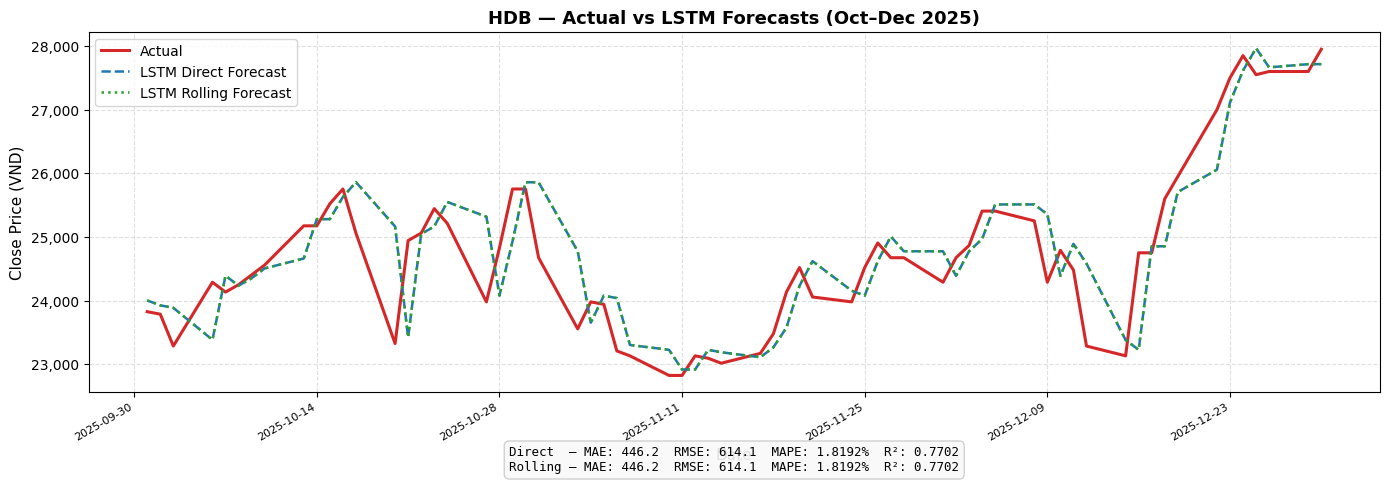

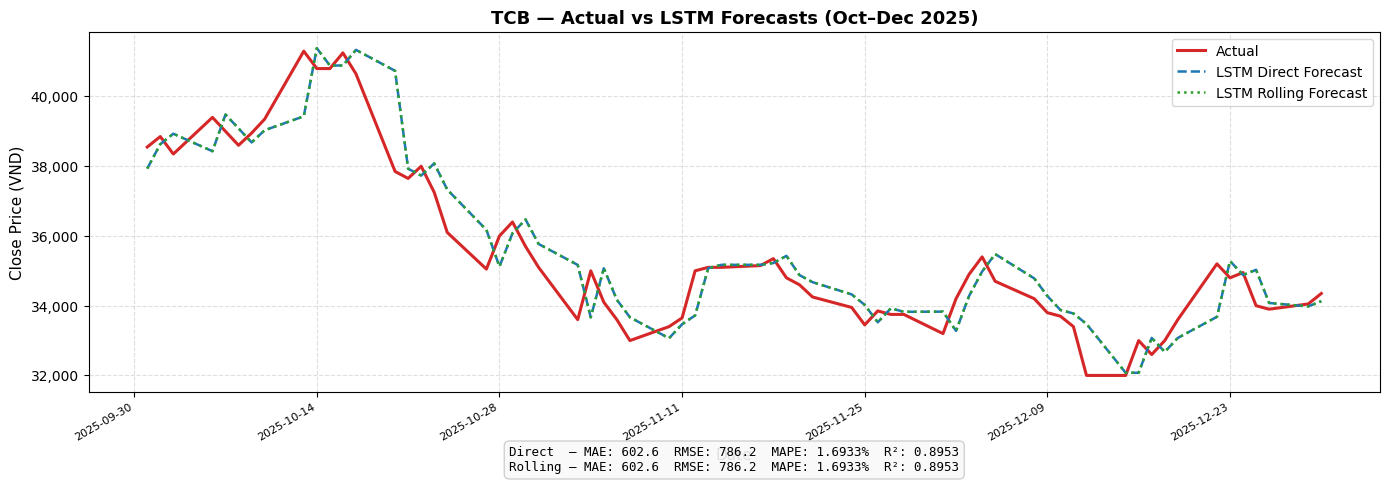

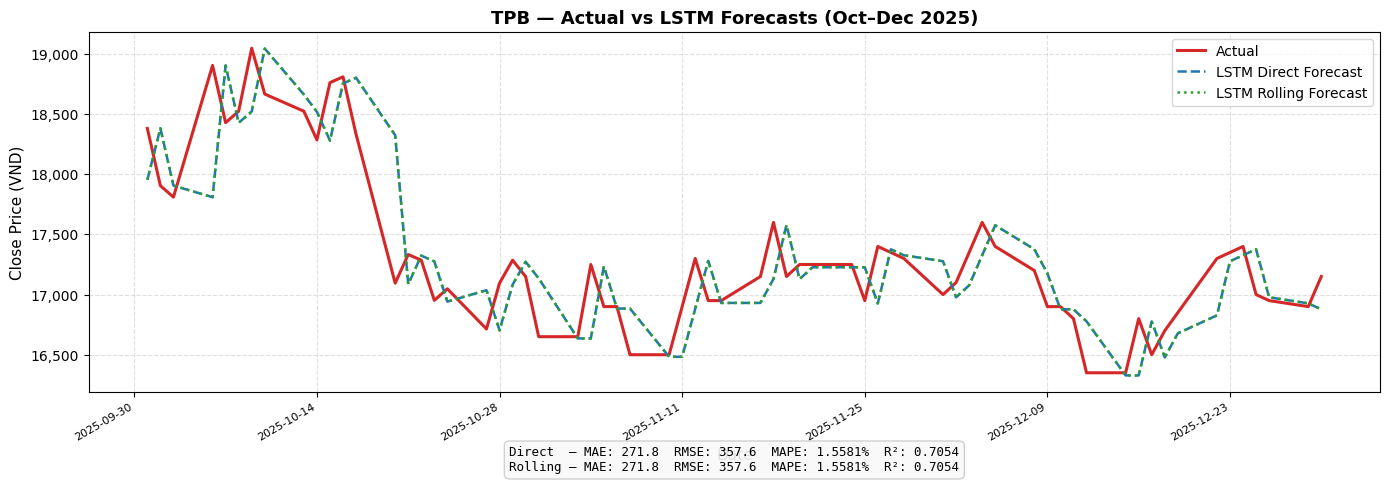

In [10]:
# ── LSTM BLOCK 6: TEST SET vs LSTM FORECAST (Direct & Rolling) ────────────────
for ticker in TICKERS:
    _, test   = stocks[ticker]
    test_idx  = pd.to_datetime(test.index)
    test_vals = test.values.astype(float)
    direct_pred  = lstm_preds[ticker].astype(float)
    rolling_pred = lstm_rolling_preds[ticker].astype(float)

    direct_row  = lstm_metrics_df[(lstm_metrics_df['Ticker'] == ticker) &
                                   (lstm_metrics_df['Forecast'] == 'Direct')].iloc[0]
    rolling_row = lstm_metrics_df[(lstm_metrics_df['Ticker'] == ticker) &
                                   (lstm_metrics_df['Forecast'] == 'Rolling')].iloc[0]

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(test_idx, test_vals,
            color='#d62728', linewidth=2.2, label='Actual')
    ax.plot(test_idx, direct_pred,
            color='#1f77b4', linewidth=1.8, linestyle='--',
            label='LSTM Direct Forecast')
    ax.plot(test_idx, rolling_pred,
            color='#2ca02c', linewidth=1.8, linestyle=':',
            label='LSTM Rolling Forecast')

    ax.set_title(f'{ticker} — Actual vs LSTM Forecasts (Oct–Dec 2025)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Close Price (VND)', fontsize=11)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=10)
    ax.grid(linestyle='--', alpha=0.4)

    metrics_text = (
        f"Direct  — MAE: {direct_row['MAE']:,.1f}  RMSE: {direct_row['RMSE']:,.1f}  "
        f"MAPE: {direct_row['MAPE(%)']:.4f}%  R²: {direct_row['R2']:.4f}\n"
        f"Rolling — MAE: {rolling_row['MAE']:,.1f}  RMSE: {rolling_row['RMSE']:,.1f}  "
        f"MAPE: {rolling_row['MAPE(%)']:.4f}%  R²: {rolling_row['R2']:.4f}"
    )
    ax.annotate(metrics_text,
                xy=(0.5, -0.22), xycoords='axes fraction',
                ha='center', fontsize=9, fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#f9f9f9',
                          edgecolor='#cccccc', alpha=0.9))

    plt.tight_layout()
    plt.show()


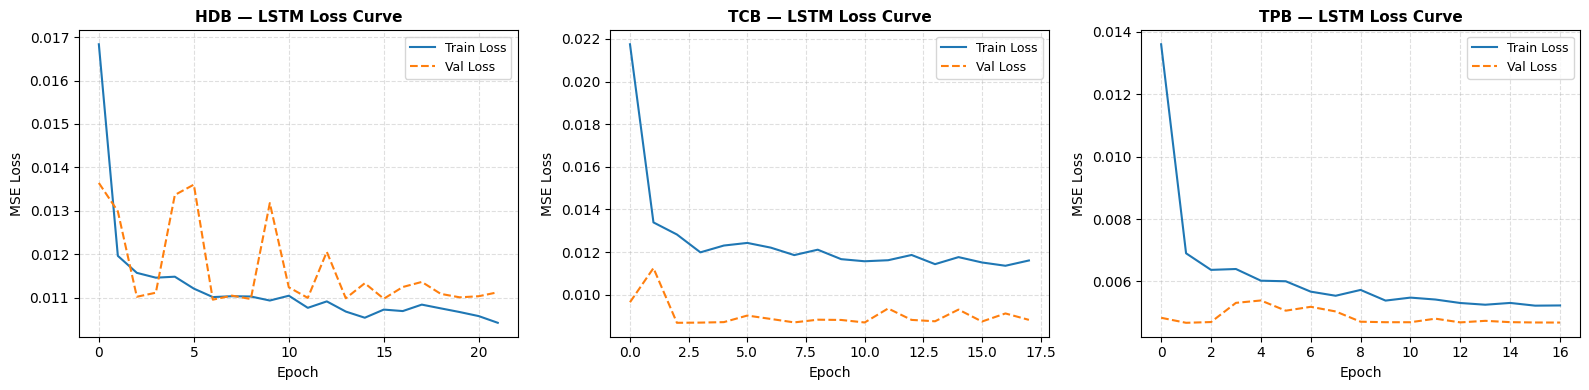

In [11]:
# ── LSTM BLOCK 7: TRAINING LOSS CURVES ────────────────────────────────────────
# Healthy training: both curves decrease and converge
# Overfitting sign: train loss keeps dropping but val loss rises

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, ticker in zip(axes, TICKERS):
    h = train_histories[ticker]
    ax.plot(h['train'], color='#1f77b4', linewidth=1.5, label='Train Loss')
    ax.plot(h['val'],   color='#ff7f0e', linewidth=1.5,
            linestyle='--', label='Val Loss')
    ax.set_title(f'{ticker} — LSTM Loss Curve', fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=9)
    ax.grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

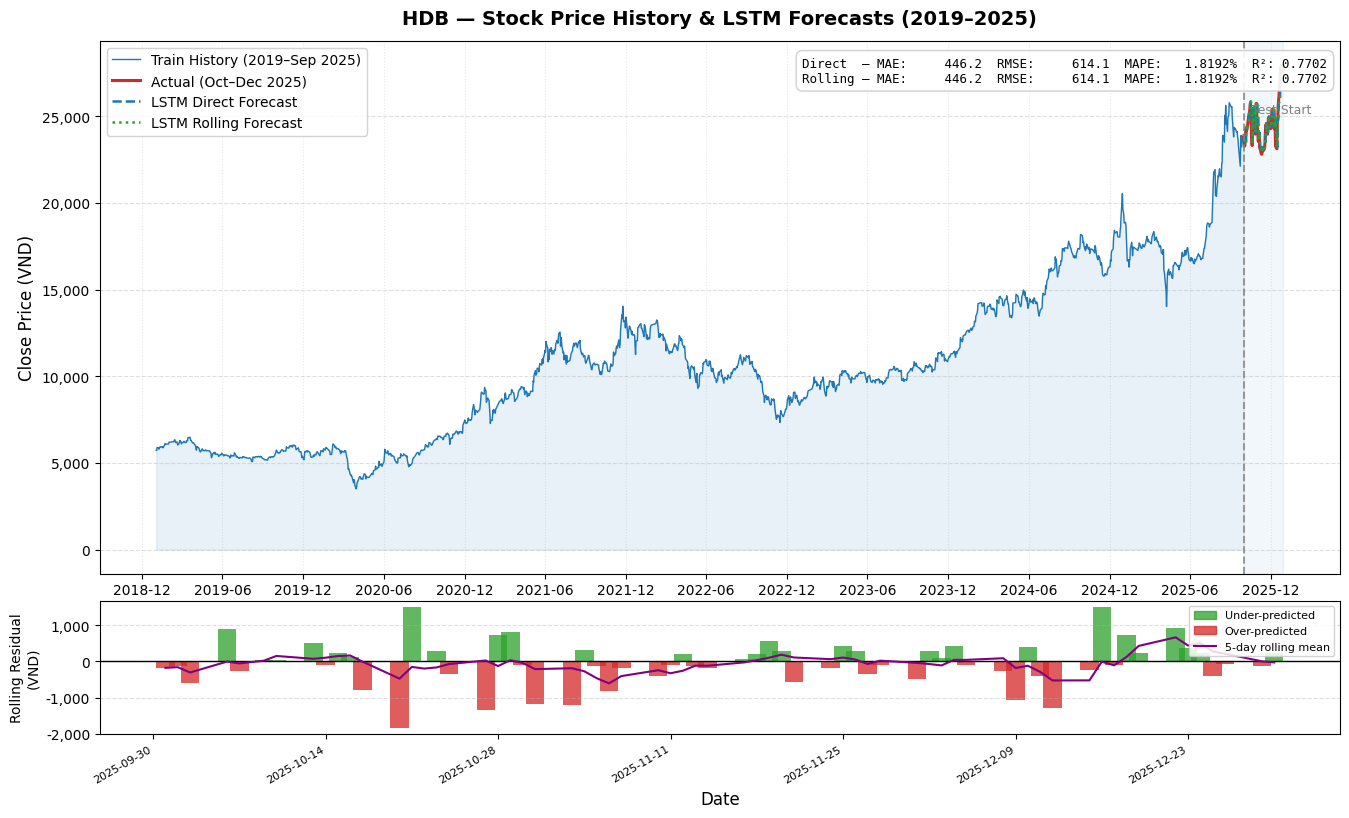

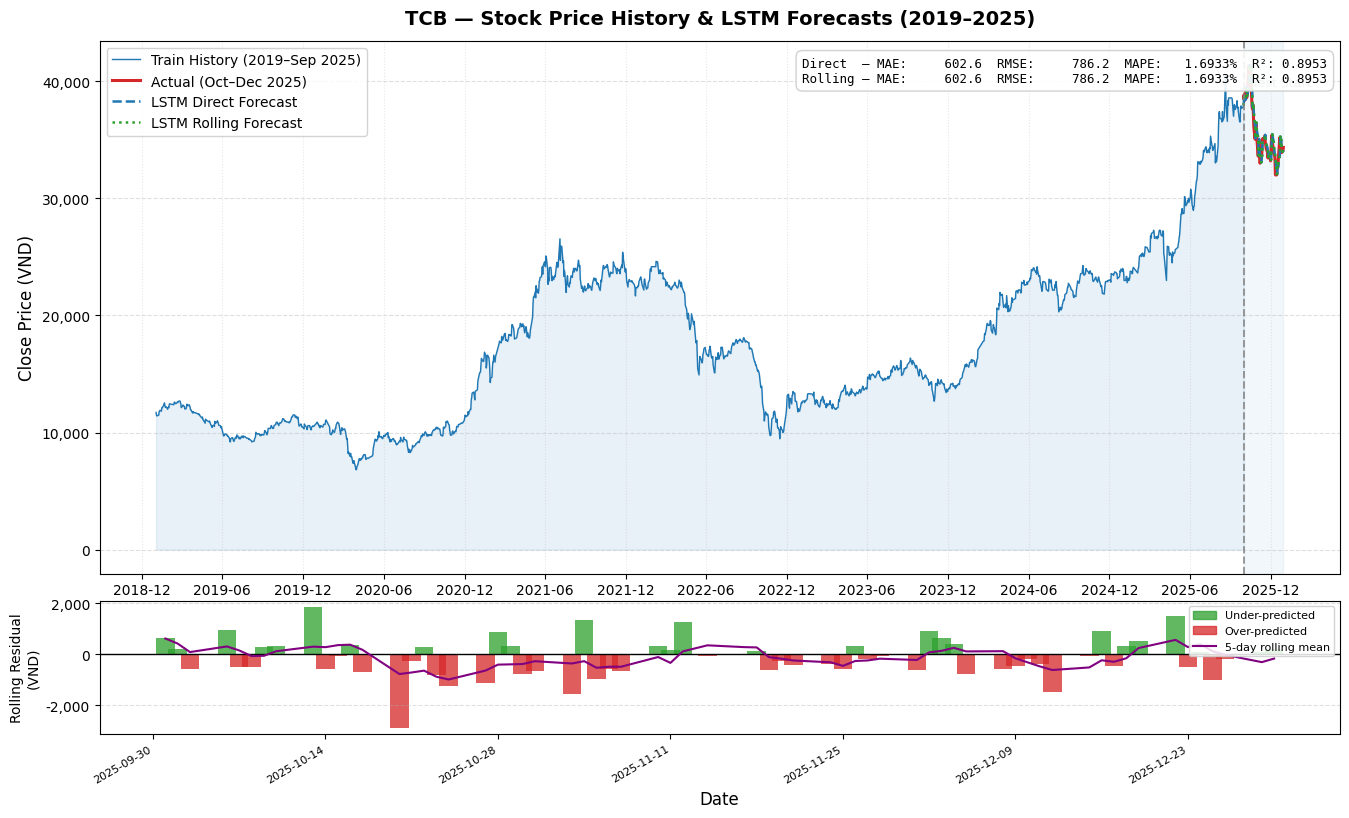

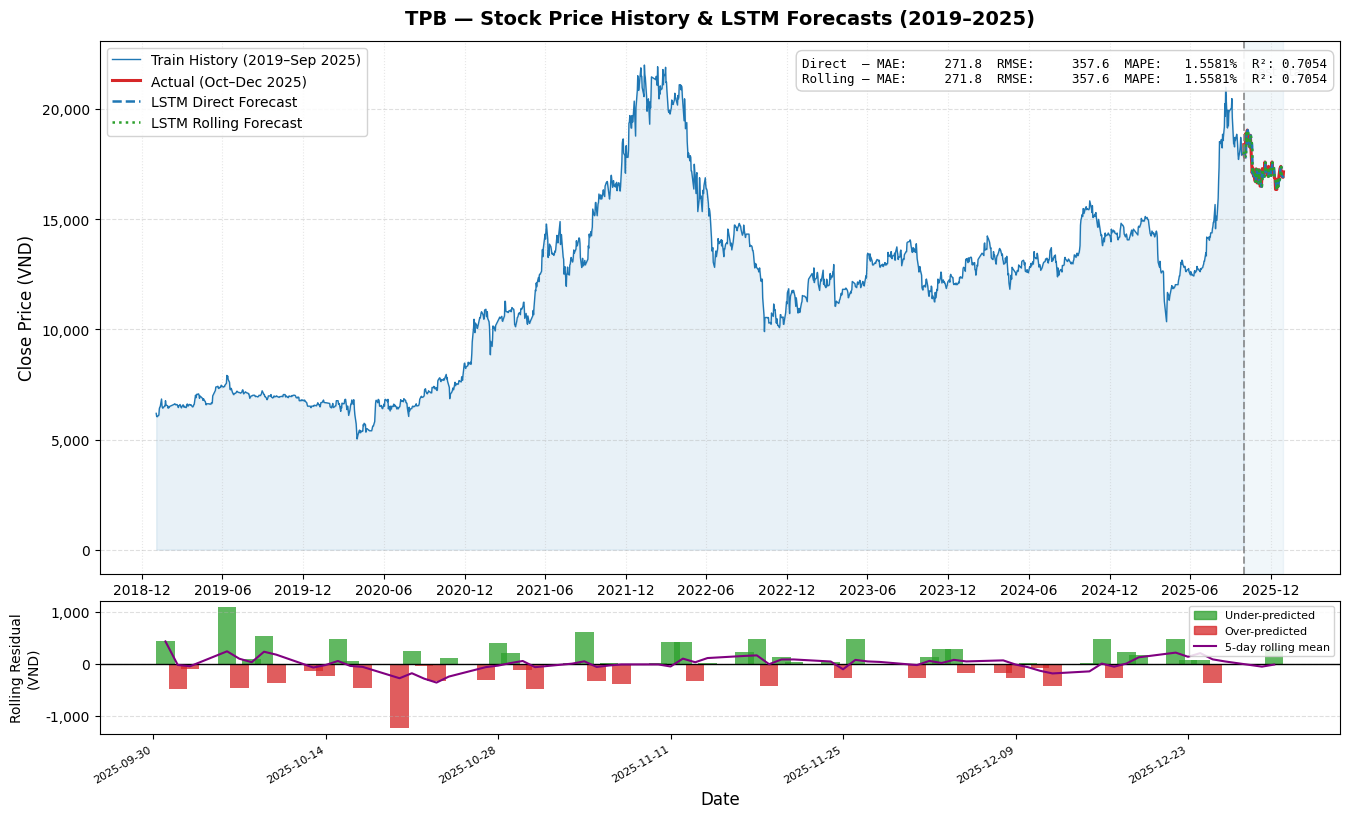

In [12]:
# ── LSTM PLOT: Full History + Direct & Rolling LSTM Forecast per Stock ─────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

for ticker in TICKERS:
    train, test  = stocks[ticker]
    direct_pred  = lstm_preds[ticker].astype(float)
    rolling_pred = lstm_rolling_preds[ticker].astype(float)

    direct_row  = lstm_metrics_df[(lstm_metrics_df['Ticker'] == ticker) &
                                   (lstm_metrics_df['Forecast'] == 'Direct')].iloc[0]
    rolling_row = lstm_metrics_df[(lstm_metrics_df['Ticker'] == ticker) &
                                   (lstm_metrics_df['Forecast'] == 'Rolling')].iloc[0]

    train_idx  = pd.to_datetime(train.index)
    test_idx   = pd.to_datetime(test.index)
    train_vals = train.values.astype(float)
    test_vals  = test.values.astype(float)

    # Residuals for the rolling forecast (more realistic evaluation)
    residuals_rolling = test_vals - rolling_pred

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(16, 9),
        gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.08},
        sharex=False
    )

    # ── TOP PANEL ─────────────────────────────────────────────────────────────
    ax1.fill_between(train_idx, train_vals, alpha=0.10, color='#1f77b4')
    ax1.plot(train_idx, train_vals,
             color='#1f77b4', linewidth=1.0,
             label='Train History (2019–Sep 2025)')

    ax1.plot(test_idx, test_vals,
             color='#d62728', linewidth=2.2,
             label='Actual (Oct–Dec 2025)')

    ax1.plot(test_idx, direct_pred,
             color='#1f77b4', linewidth=1.8, linestyle='--',
             label='LSTM Direct Forecast')

    ax1.plot(test_idx, rolling_pred,
             color='#2ca02c', linewidth=1.8, linestyle=':',
             label='LSTM Rolling Forecast')

    ax1.axvspan(test_idx[0], test_idx[-1], alpha=0.06, color='#1f77b4')
    ax1.axvline(x=test_idx[0], color='gray', linestyle='--', linewidth=1.4, alpha=0.8)
    ax1.text(test_idx[0], train_vals.max(),
             '  Test Start', color='gray', fontsize=9, va='top')

    metrics_text = (
        f"Direct  — MAE:{direct_row['MAE']:>10,.1f}  RMSE:{direct_row['RMSE']:>10,.1f}  "
        f"MAPE:{direct_row['MAPE(%)']:>9.4f}%  R²:{direct_row['R2']:>7.4f}\n"
        f"Rolling — MAE:{rolling_row['MAE']:>10,.1f}  RMSE:{rolling_row['RMSE']:>10,.1f}  "
        f"MAPE:{rolling_row['MAPE(%)']:>9.4f}%  R²:{rolling_row['R2']:>7.4f}"
    )
    ax1.annotate(
        metrics_text,
        xy=(0.99, 0.97), xycoords='axes fraction',
        ha='right', va='top', fontsize=9,
        fontfamily='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor='#cccccc', alpha=0.9)
    )

    ax1.set_title(
        f'{ticker} — Stock Price History & LSTM Forecasts (2019–2025)',
        fontsize=14, fontweight='bold', pad=12
    )
    ax1.set_ylabel('Close Price (VND)', fontsize=12)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0, ha='center')
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax1.legend(loc='upper left', fontsize=10, framealpha=0.85)
    ax1.grid(axis='y', linestyle='--', alpha=0.4)
    ax1.grid(axis='x', linestyle=':', alpha=0.3)

    # ── BOTTOM PANEL: rolling forecast residuals ───────────────────────────────
    bar_colors = ['#2ca02c' if r >= 0 else '#d62728' for r in residuals_rolling]
    ax2.bar(test_idx, residuals_rolling, color=bar_colors, width=1.5, alpha=0.75)
    ax2.axhline(0, color='black', linewidth=1.0)

    rolling_mean = (pd.Series(residuals_rolling, index=test_idx)
                    .rolling(window=5, min_periods=1).mean())
    ax2.plot(test_idx, rolling_mean.values,
             color='purple', linewidth=1.5, label='5-day rolling mean (residual)')

    ax2.set_ylabel('Rolling Residual\n(VND)', fontsize=10)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax2.grid(axis='y', linestyle='--', alpha=0.4)

    green_patch = mpatches.Patch(color='#2ca02c', alpha=0.75, label='Under-predicted')
    red_patch   = mpatches.Patch(color='#d62728', alpha=0.75, label='Over-predicted')
    purple_line = plt.Line2D([0], [0], color='purple', linewidth=1.5,
                              label='5-day rolling mean')
    ax2.legend(handles=[green_patch, red_patch, purple_line],
               loc='upper right', fontsize=8, framealpha=0.85)

    plt.tight_layout()
    plt.show()
